# Análise de Dados - Tênis de Corrida RunRepeat

## 5. Visualização Multivariada (3D ou mais variáveis)

Análise de múltiplas variáveis simultaneamente usando scatter plots com cor/tamanho e pairplots.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

df = pd.read_csv('tenis_scraper_runrepeat/dados_finais/runrepeat_shoes_complete.csv')
print(f'✅ Dataset carregado: {df.shape}')

✅ Dataset carregado: (530, 46)


## 5.1 Scatter Plot com Cor e Tamanho (4 variáveis)

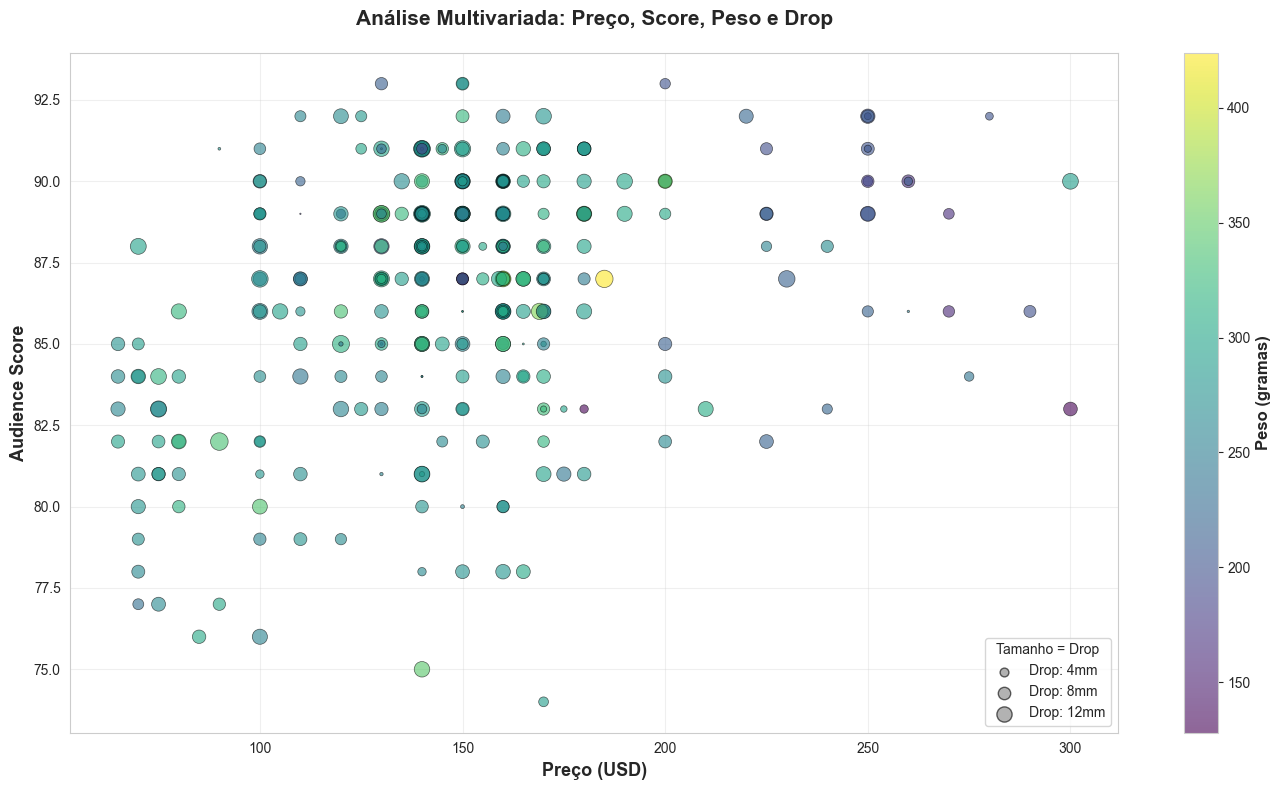


📊 INSIGHTS:
• Cor (peso): Tênis mais pesados (amarelo) tendem a ser mais baratos
• Tamanho (drop): Drops maiores são comuns em diferentes faixas de preço
• Não há correlação forte entre as 4 variáveis


In [6]:
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter com 4 variáveis: x, y, cor, tamanho
scatter = ax.scatter(df['price_usd'], df['audience_score'],
                     c=df['weight_grams'], s=df['drop_mm']*10,
                     alpha=0.6, cmap='viridis', edgecolors='black', linewidth=0.5)

ax.set_xlabel('Preço (USD)', fontsize=13, fontweight='bold')
ax.set_ylabel('Audience Score', fontsize=13, fontweight='bold')
ax.set_title('Análise Multivariada: Preço, Score, Peso e Drop', fontsize=15, fontweight='bold', pad=20)
ax.grid(alpha=0.3)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Peso (gramas)', fontsize=12, fontweight='bold')

# Legenda para tamanho
handles = [plt.scatter([], [], s=drop*10, c='gray', alpha=0.6, edgecolors='black') 
           for drop in [4, 8, 12]]
labels = ['Drop: 4mm', 'Drop: 8mm', 'Drop: 12mm']
ax.legend(handles, labels, loc='lower right', title='Tamanho = Drop', fontsize=10)

plt.tight_layout()
plt.show()

print('\n📊 INSIGHTS:')
print('• Cor (peso): Tênis mais pesados (amarelo) tendem a ser mais baratos')
print('• Tamanho (drop): Drops maiores são comuns em diferentes faixas de preço')
print('• Não há correlação forte entre as 4 variáveis')

## 5.2 Pairplot - Matriz de Dispersão

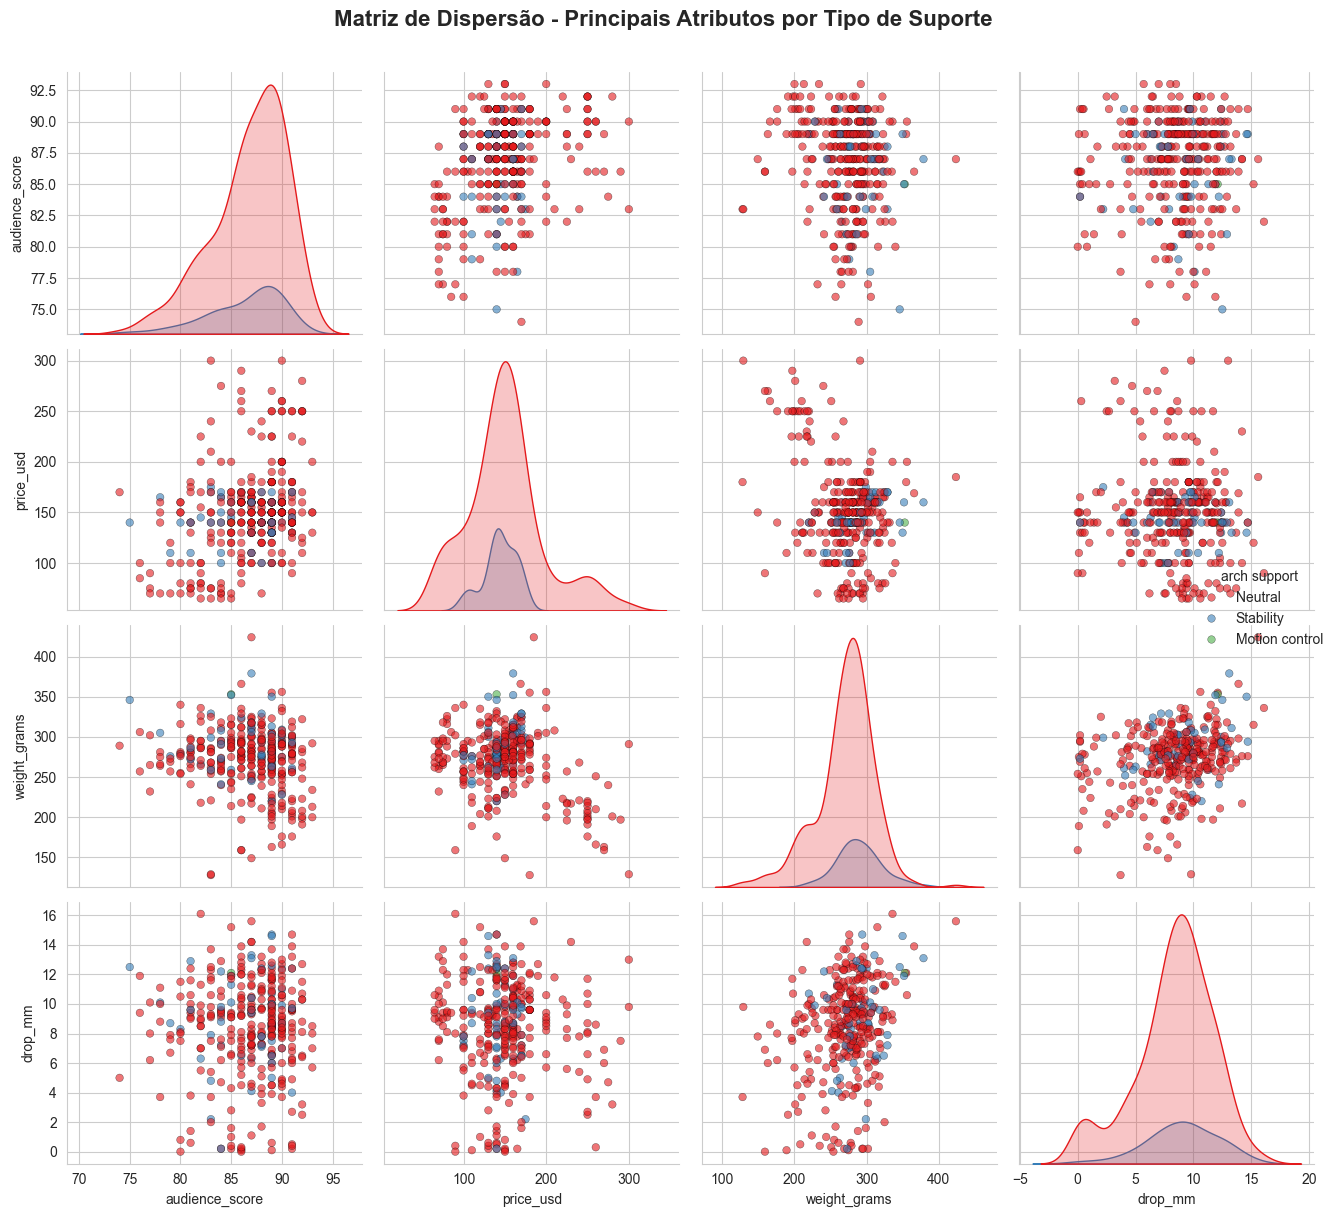


📊 INSIGHTS DO PAIRPLOT:
• Distribuições: Audience score concentrado em valores altos
• Preços: Distribuição com cauda à direita
• Peso: Distribuição aproximadamente normal
• Drop: Alguns valores preferidos (8mm, 10mm)
• Tipos de suporte se sobrepõem bastante - difícil distinção visual


In [7]:
# Selecionar colunas numéricas principais
cols_to_plot = ['audience_score', 'price_usd', 'weight_grams', 'drop_mm']
df_num = df[cols_to_plot + ['arch support']].dropna()

# Criar pairplot
pairplot = sns.pairplot(df_num, hue='arch support', 
                        palette='Set1', 
                        diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'black', 'linewidth': 0.3},
                        height=3)

pairplot.fig.suptitle('Matriz de Dispersão - Principais Atributos por Tipo de Suporte', 
                     fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n📊 INSIGHTS DO PAIRPLOT:')
print('• Distribuições: Audience score concentrado em valores altos')
print('• Preços: Distribuição com cauda à direita')
print('• Peso: Distribuição aproximadamente normal')
print('• Drop: Alguns valores preferidos (8mm, 10mm)')
print('• Tipos de suporte se sobrepõem bastante - difícil distinção visual')

## 5.3 Heatmap de Correlação

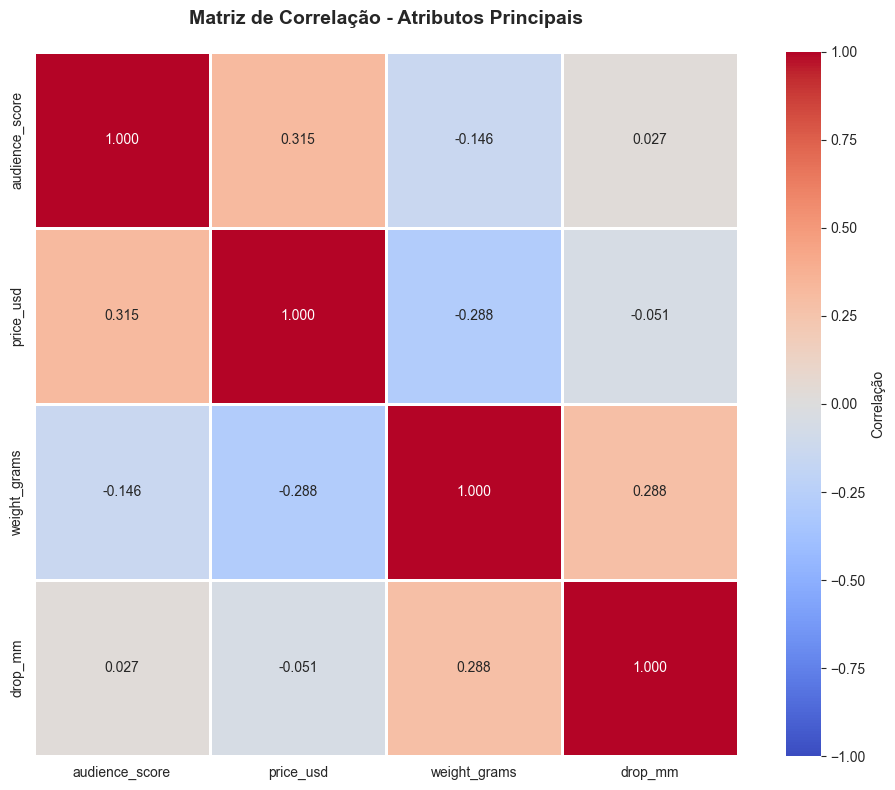


📊 ANÁLISE DE CORRELAÇÕES:
• audience_score ↔ price_usd: 0.315
• audience_score ↔ weight_grams: -0.146
• price_usd ↔ weight_grams: -0.288
• weight_grams ↔ drop_mm: 0.288

💡 CONCLUSÃO: Correlações fracas sugerem que os atributos são independentes


In [8]:
# Calcular matriz de correlação
corr_matrix = df[cols_to_plot].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'label': 'Correlação'},
            ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlação - Atributos Principais', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\n📊 ANÁLISE DE CORRELAÇÕES:')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.1:
            print(f'• {col1} ↔ {col2}: {corr_val:.3f}')

print('\n💡 CONCLUSÃO: Correlações fracas sugerem que os atributos são independentes')

## 5.4 Conclusões da Análise Multivariada

### 🎯 Principais Descobertas:

1. **Independência de Variáveis:** Os atributos principais são largamente independentes
2. **Qualidade vs Preço:** Não há correlação forte - tênis caros não são necessariamente melhores
3. **Peso e Drop:** Tênis leves podem ter diferentes drops
4. **Tipos de Suporte:** Distribuições similares entre tipos

### 📊 Insights para o Consumidor:
- Escolha baseada em necessidades específicas, não apenas em preço
- Marcas diferentes têm abordagens variadas
- Peso e drop devem ser considerados conforme tipo de corrida

✅ **Análise completa realizada com sucesso!**